<a href="https://colab.research.google.com/github/LalithaJanneti/Deep-Learning-Journey/blob/main/cnn_cifar10_image_classiffication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,datasets

In [ ]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

here y train is in 2D but for our classification we need 1D so convert 2d into 1d

In [ ]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test=y_test.reshape(-1,)

In [ ]:
classes=["aeroplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [ ]:
def plot_sample(X,y,index):
  plt.figure(figsize=(10,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

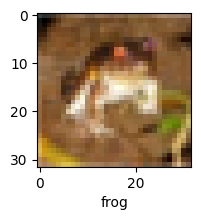

In [ ]:
plot_sample(X_train,y_train,0)

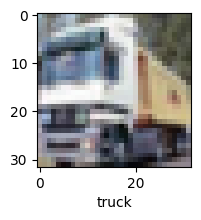

In [ ]:
plot_sample(X_train,y_train,1)

Normalize the training data in between 0 to 1

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

ANN for image classification

In [ ]:
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10,activation='softmax')
])
ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann.fit(X_train,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 80ms/step - accuracy: 0.3530 - loss: 1.8116
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 80ms/step - accuracy: 0.4290 - loss: 1.6238
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 84ms/step - accuracy: 0.4558 - loss: 1.5411
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 79ms/step - accuracy: 0.4743 - loss: 1.4844
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.4958 - loss: 1.4311


you can see that by the end of 5 epochs we got only accuracy of 49%

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
y_pred=ann.predict(X_test)
y_pred_classes=[np.argmax(element) for element in y_pred]
print("Classification Report:\n",classification_report(y_test,y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.54      0.53      1000
           1       0.59      0.65      0.62      1000
           2       0.46      0.19      0.26      1000
           3       0.42      0.16      0.23      1000
           4       0.35      0.55      0.42      1000
           5       0.39      0.41      0.40      1000
           6       0.53      0.54      0.54      1000
           7       0.57      0.52      0.55      1000
           8       0.55      0.70      0.61      1000
           9       0.51      0.61      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.47     10000
weighted avg       0.49      0.49      0.47     10000



Now lets build convolutional neural network to train our images

In [ ]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')

])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4623 - loss: 1.4932
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.5986 - loss: 1.1422
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6508 - loss: 1.0047
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6804 - loss: 0.9194
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7029 - loss: 0.8563
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7217 - loss: 0.7998
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7367 - loss: 0.7541
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.7517 - loss: 0.7139
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7608 - loss: 0.6838
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7735 - loss: 0.6491


In [ ]:
y_pred=cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([[1.36836607e-03, 1.64349141e-04, 3.29329143e-03, 8.01356614e-01,
        1.03294515e-04, 7.53626972e-02, 2.34278035e-03, 7.45550846e-04,
        1.15116298e-01, 1.46688355e-04],
       [2.26448965e-03, 1.46134035e-03, 1.23669122e-06, 1.86210727e-08,
        4.60050586e-07, 2.51456145e-09, 6.07557893e-10, 1.25692642e-11,
        9.96271491e-01, 9.27876215e-07],
       [7.74412006e-02, 5.03983200e-02, 1.40118338e-02, 3.62346065e-03,
        1.87088735e-02, 1.06631036e-04, 3.16288351e-05, 9.83267906e-04,
        8.28285694e-01, 6.40902249e-03],
       [9.02639270e-01, 2.96909222e-03, 3.61273368e-03, 1.17347583e-04,
        7.97321089e-04, 1.04437208e-06, 8.09203448e-06, 4.75483466e-06,
        8.98420811e-02, 8.30194858e-06],
       [5.73435182e-06, 3.27409944e-05, 9.67183709e-02, 4.87816483e-02,
        4.72913593e-01, 1.00732048e-03, 3.80405039e-01, 5.23590643e-06,
        1.28998625e-04, 1.21164953e-06]], dtype=float32)

In [ ]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

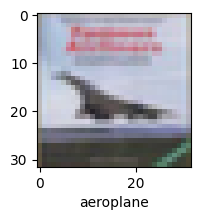

In [ ]:
plot_sample(X_test,y_test,3)

In [ ]:
classes[y_classes[3]]

'aeroplane'

In [ ]:
classes[y_classes[2]]

'ship'